# Division 1 Wrestling Exporatory Data Analysis

This exploratory data analysis examines NCAA Division I wrestling match data from the 2013–2014 season through the present. The dataset includes  unique matches between individual wrestlers, with each bout recorded once regardless of whether the wrestler appeared as the primary or opponent.

The goal of this analysis is to uncover patterns and trends across seasons, teams, weight classes, and individual wrestlers. Key areas of focus include win distributions, bonus point frequency, team and wrestler performance over time, and the evolving dynamics of collegiate wrestling.

Insights from this EDA will inform feature engineering and modeling strategies for downstream predictive tasks, such as forecasting match outcomes or identifying performance trends.

In [47]:
# Importing packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os
import random

In [48]:
# Importing data
matches = pd.read_csv('../data/clean/d1_results_unique.csv')

In [49]:
# Quick view of dataset columns
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263422 entries, 0 to 263421
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   season           263422 non-null  object
 1   date             263422 non-null  object
 2   event            263422 non-null  object
 3   weight_class     263422 non-null  int64 
 4   wrestler         263422 non-null  object
 5   wrestler_id      263422 non-null  int64 
 6   wrestler_school  263422 non-null  object
 7   opponent         263422 non-null  object
 8   opponent_id      263422 non-null  int64 
 9   opponent_school  263422 non-null  object
 10  result           263422 non-null  object
 11  result_type      263422 non-null  object
 12  score            263422 non-null  object
 13  match_duration   263422 non-null  object
dtypes: int64(3), object(11)
memory usage: 28.1+ MB


In [50]:
# Helper function to title, label the axes, and despine the graphs
def label_and_despine(title = '', xlabel = '', ylabel = '', despine = True):
    if despine:
        sns.despine()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

# Overview of Time Period

Since all of the data has already been cleaned and deduplicated, I will jump right into the analysis, starting with a higher level overview of trends across the entire time period.

First off I want to look at the different result types, and how frequently they appear in the dataset.

In [51]:
# Getting the counts for each result type
counts = {}

for result in matches['result_type'].unique():
    counts[result] = (matches['result_type'] == result).sum()

for result, count in counts.items():
    print(f'{count} matches resulted in {result}')

7252 matches resulted in MFOR
124518 matches resulted in DEC
43509 matches resulted in MD
988 matches resulted in TB-2
48476 matches resulted in FALL
116 matches resulted in DEF
25326 matches resulted in TF
8537 matches resulted in SV-1
253 matches resulted in DQ
318 matches resulted in SV-2
1431 matches resulted in TB-1
2142 matches resulted in INJ
76 matches resulted in TB-3
57 matches resulted in SV-3
12 matches resulted in FOR
411 matches resulted in CMFF


It definitely seems like some of the categories should be combined to make overall analysis easier, but I'll make a bar graph to double check

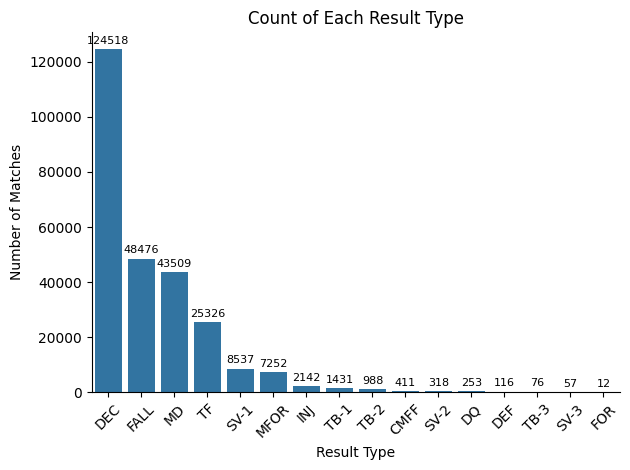

In [52]:
# Bar chart of count of each result
g = sns.countplot(data=matches, x='result_type', order=matches['result_type'].value_counts().index)

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 2000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=8
    )

label_and_despine('Count of Each Result Type', 'Result Type', 'Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()

It is pretty easy to tell that there are a bunch of result types that are such small portions of the overall data that there isn't much reason to graph them as separate columns.

For that reason, I'm going to combine some of the columns to make the graph easier to read. 

The new categories will be: 
- OT: `SV-1`, `SV-2`, `SV-3`, `TB-1`, `TB-2`, `TB-3`
- FF: `FOR`, `CMFF`, `MFOR`
- Other: `INJ`, `DQ`, `DEF`

With `DEC`, `FALL`, `TF`, and `MD` remaining the same

In [53]:
# Creating a new df and modifying the result_type to create new categories
recategorized = matches.copy(deep=True)
recategorized.loc[recategorized['result_type'].isin(['SV-1', 'SV-2', 'SV-3', 'TB-1', 'TB-2', 'TB-3']), 'result_type'] = 'OT'
recategorized.loc[recategorized['result_type'].isin(['FOR', 'CMFF', 'MFOR']), 'result_type'] = 'FF'
recategorized.loc[recategorized['result_type'].isin(['INJ', 'DQ', 'DEF']), 'result_type'] = 'Other'

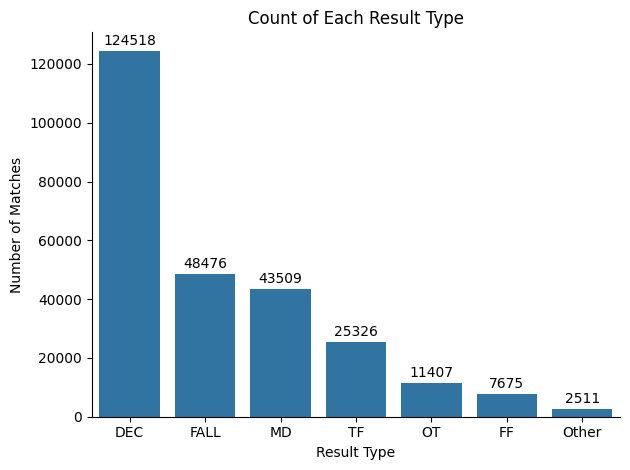

In [54]:
# Count bar chart of recategorized result types
g = sns.countplot(data=recategorized, x='result_type', order=recategorized['result_type'].value_counts().index)

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 2000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=10
    )

label_and_despine('Count of Each Result Type', 'Result Type', 'Number of Matches')
plt.tight_layout()
plt.savefig('../output/figures/result_type_counts.png')

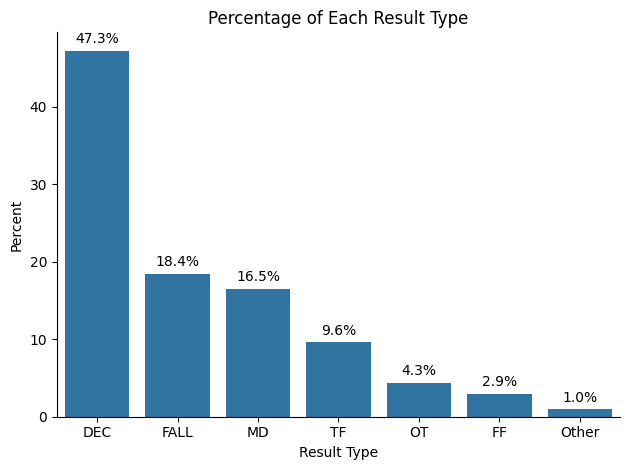

In [55]:
# Percentage bar chart of recategorized result types
g = sns.countplot(data=recategorized, x='result_type', order=recategorized['result_type'].value_counts().index, stat='percent')

# Add percent on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )
    
label_and_despine('Percentage of Each Result Type', 'Result Type', 'Percent')
plt.tight_layout()
plt.savefig('../output/figures/result_type_percentage.png')

This seems like a pretty clear graph, but it doesn't account for the fact that falls can take place in overtime as well.

In [56]:
# Finding how many falls occurred in overtime (indicated by a match_duration of more than seven minutes)
len(recategorized[(recategorized['result_type'] == 'FALL') & (recategorized['match_duration'] > '7:00')])

298

Only 298 falls in overtime is a very small relative number so it would have minimal impact on the graphes above.

To truly rectify the issue though, I'll plot the number of matches that end in regulation versus the number that end in overtime.

In [57]:
# Converting match_duration to seconds to make overtime column
def duration_to_seconds(duration_str):
    try:
        minutes, seconds = map(int, duration_str.split(":"))
        return minutes * 60 + seconds
    except:
        return None

# Convert to seconds
recategorized["duration_seconds"] = recategorized["match_duration"].apply(duration_to_seconds)

# Create is_overtime column (True if > 7 minutes)
recategorized["is_overtime"] = recategorized["duration_seconds"] > 420

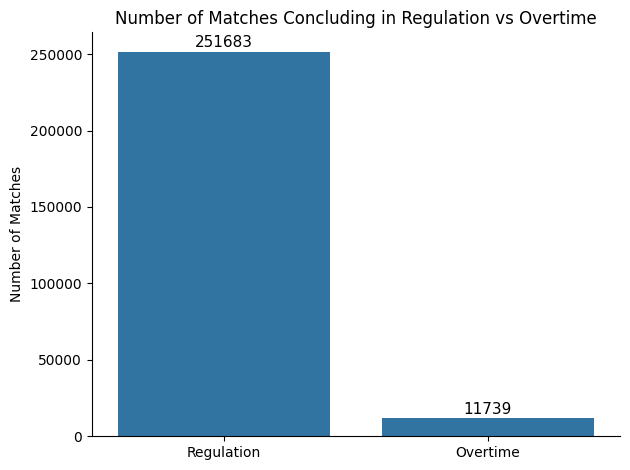

In [58]:
# Count of regulation versus overtime matches
recategorized['is_overtime'] = recategorized['is_overtime'].replace({True : 'Overtime', False : 'Regulation'})
g = sns.countplot(data=recategorized, x='is_overtime')

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 3000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=11
    )

label_and_despine('Number of Matches Concluding in Regulation vs Overtime', ylabel='Number of Matches')
plt.tight_layout()
plt.savefig('../output/figures/overtime_counts.png')

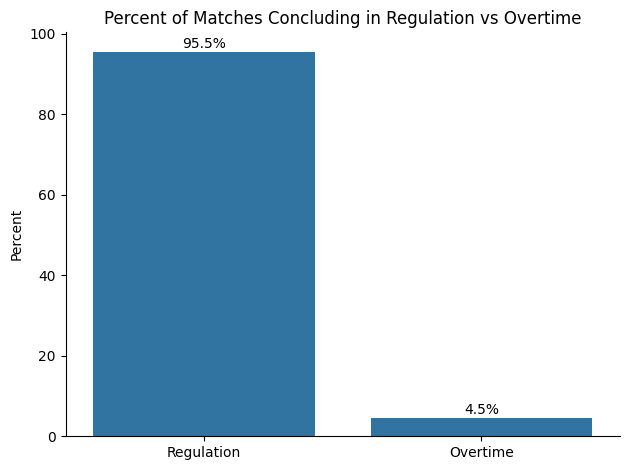

In [59]:
# Percent of regulation versus overtime matches
g = sns.countplot(data=recategorized, x='is_overtime', stat='percent')

# Add percent on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )

label_and_despine('Percent of Matches Concluding in Regulation vs Overtime', ylabel='Percent')
plt.tight_layout()
plt.savefig('../output/figures/overtime_percentage.png')

That's incredible! I did not expect such a small percentage of matches to go to overtime. It makes sense though, since many wrestlers push for scoring opportunities late in matches to avoid overtime, where they know a single mistake could cost them a win.

I'd expect that most teams have wrestled a similar number of matches, but I wonder if the more dominant teams have more matches since their wrestlers typically wrestle more in tournaments (since they advance farther than worse wrestlers)

In [60]:
# Combining wrestler_school and opponent_school column counts to get full team list
team_counts = pd.concat([matches['wrestler_school'], matches['opponent_school']]).value_counts().sort_values(ascending=False)
team_counts.index = team_counts.index.str.upper()

In [61]:
# Helper function to pull team names from already scraped data folders
from pathlib import Path
def get_folder_names(path):
    return [p.name for p in Path(path).iterdir() if p.is_dir()]

# List of all D1 teams between 2013 and 2025
teams = [team.replace('_', ' ').upper() for team in get_folder_names('../data/raw/team_results')]

In [62]:
# Reduce and condense list to only D1 teams
team_counts = team_counts.loc[team_counts.index.isin(teams)]
team_counts = team_counts.groupby(team_counts.index).sum()
team_counts_sorted = team_counts.sort_values()

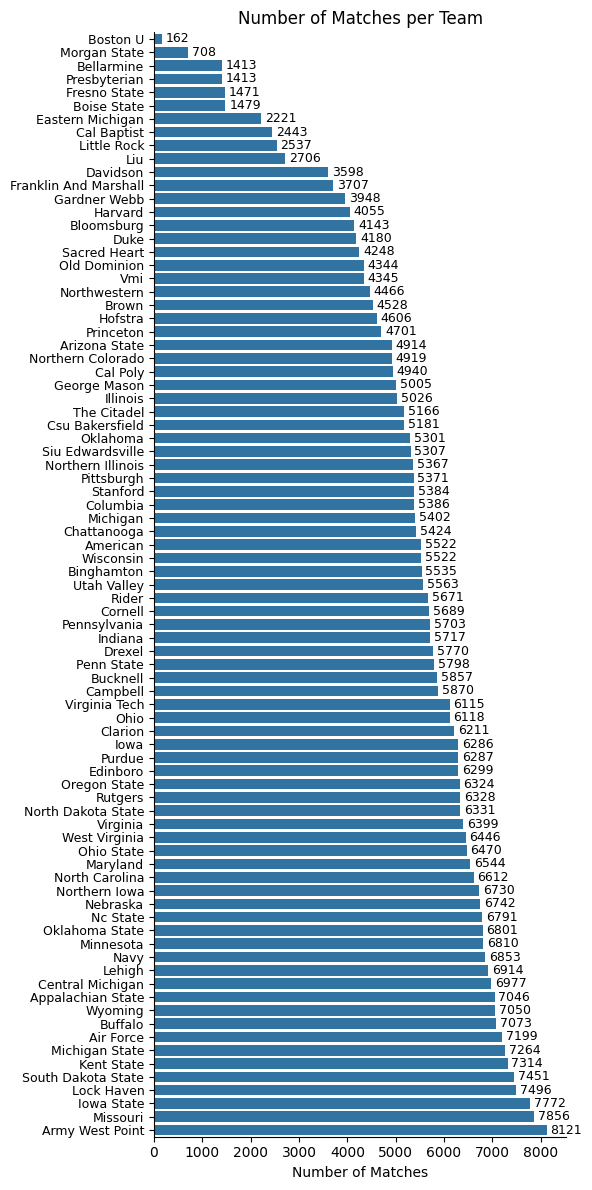

In [63]:
# Plotting the number of matches per team
plt.figure(figsize=(6, 12))
g = sns.barplot(x=team_counts_sorted, y=team_counts_sorted.index.str.title())

# Add counts on top of each bar
for p in g.patches:
    width = p.get_width()
    g.text(
        x=width + 80,
        y=p.get_y() + p.get_height() / 2, 
        s=f'{width:.0f}',
        va='center',
        fontsize=9
    )

plt.yticks(fontsize=9)
label_and_despine('Number of Matches per Team', xlabel='Number of Matches')
plt.tight_layout()
plt.savefig('../output/figures/total_matches_per_team.png')

This is quite an interesting result. It turns out that the historically better teams don't have more matches than worse teams. I suppose dual meet schedule plays more of a role than tournament success, which does make sense since each additional dual meet is a guaranteed number of matches. Understandably, the teams with the fewest matches are those that were not in Division 1 for the entirety of the time period such as Presbytarian and Morgan State.

I also am interested by how often matches end with bonus points (match decided by major decision, technical fall, or fall).

In [64]:
# Creating new column to track whether match resulted in bonus points
recategorized.loc[:,'is_bonus'] = recategorized['result_type'].isin(['MD', 'TF', 'FALL'])

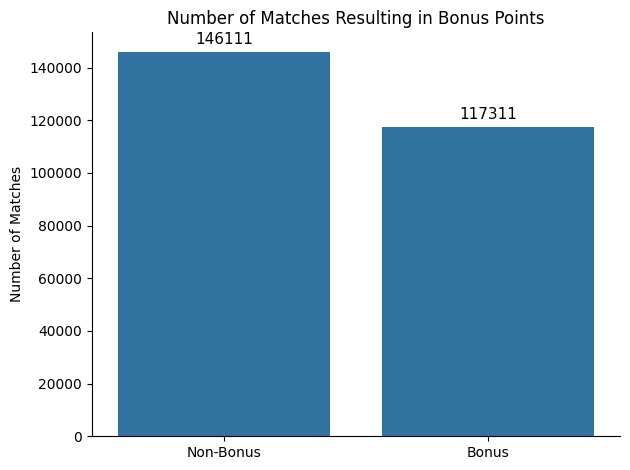

In [65]:
recategorized['is_bonus'] = recategorized['is_bonus'].replace({True : 'Bonus', False : 'Non-Bonus'})
g = sns.countplot(data=recategorized, x='is_bonus')

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 3000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=11
    )

label_and_despine('Number of Matches Resulting in Bonus Points', ylabel='Number of Matches')
plt.tight_layout()
plt.savefig('../output/figures/bonus_point_counts.png')

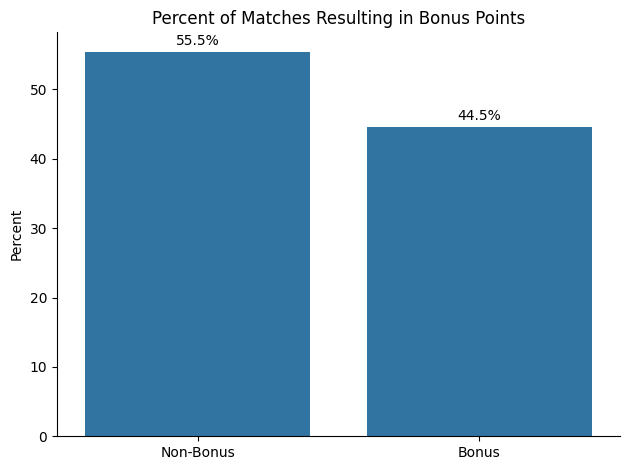

In [66]:
g = sns.countplot(data=recategorized, x='is_bonus', stat='percent')

# Add percent on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )

label_and_despine('Percent of Matches Resulting in Bonus Points', ylabel='Percent')
plt.tight_layout()
plt.savefig('../output/figures/bonus_point_percentage.png')

# Season by Season Analysis

Now that I've looked over some more general trends across the time period, I'll dive into some of the differences between each season.

First I'll look at the overall number of matches per season, and how that has fluctuated over the years.

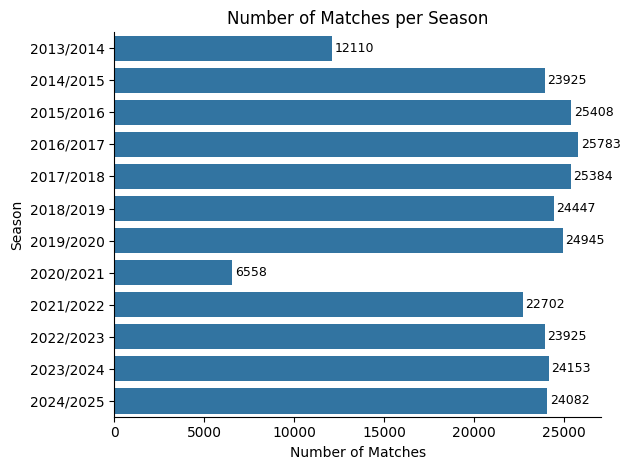

In [67]:
g = sns.countplot(data=matches, y='season')

# Add counts on top of each bar
for p in g.patches:
    width = p.get_width()
    g.text(
        x=width + 150,
        y=p.get_y() + p.get_height() / 2, 
        s=f'{width:.0f}',
        va='center',
        fontsize=9
    )

label_and_despine('Number of Matches per Season','Number of Matches', 'Season')
plt.tight_layout()
plt.savefig('../output/figures/total_matches_per_season.png')

This is about what I expected to see, overall consistency in number of matches across the seasons with a sharp hole during the shortened 2020/2021 season due to the COVID-19 Pandemic.

I would assume that the 2013/2014 number is simply due to missing data from the website that I scraped from, therefore the data doesn't accurately represent that season. This may be something to consider during modeling, but I doubt this would have an substantive effect.

Next I want to look at how the frequency of result types has changed over the years.

In [68]:
# Can adjust result_type column since all matches labeled 'OT' are actually decisions (since falls in overtime are labeled as 'FALL')
recategorized.loc[recategorized['result_type'] == 'OT', 'result_type'] = 'DEC'

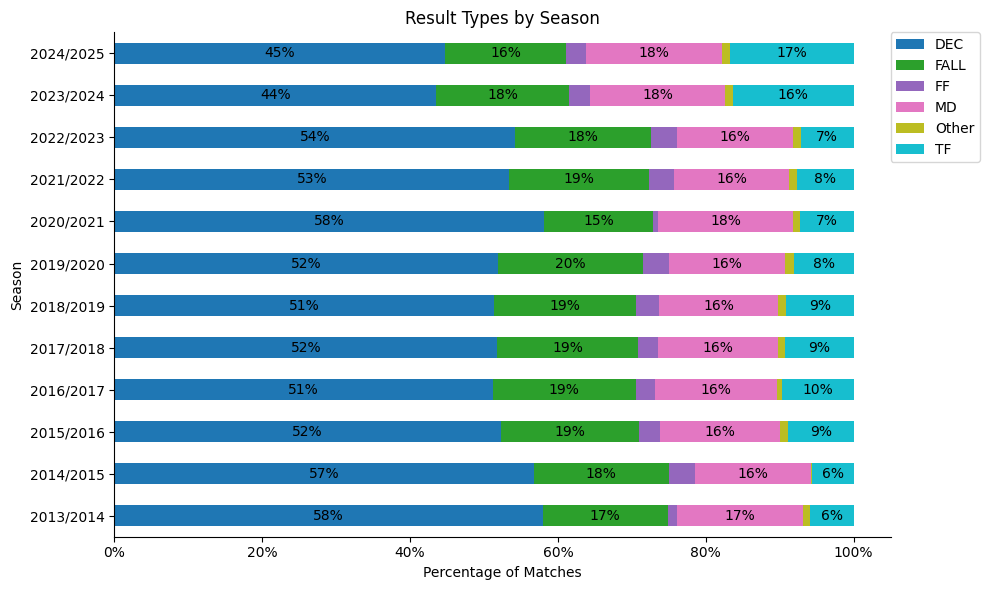

In [69]:
# Plotting match counts by season and using color to differentiate result_types
plot_data = recategorized.groupby('season')['result_type'].value_counts(normalize=True).unstack()
g = plot_data.plot(kind='barh', stacked=True, figsize=(10,6), cmap='tab10')

g.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Annotating with result type percentages
for i, (index, row) in enumerate(plot_data.iterrows()):
    cumulative = 0
    for result in plot_data.columns:
        value = row[result]
        if pd.notna(value) and value > 0.05:  # only annotate if >5%
            g.text(cumulative + value / 2, i, f'{value:.0%}', va='center', ha='center', fontsize=10)
        cumulative += value

label_and_despine('Result Types by Season', 'Percentage of Matches', 'Season')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../output/figures/result_types_by_season.png')

With the addition of the three point takedown, the fact that technical falls have occured more frequently in the past two seasons makes complete sense to me, and the fact that everything else has stayed relatively similar also is understandable, given that the rules of collegiate wrestling haven't changed too much. This also demonstrates that the probability of bonus point matches has stayed relatively consistent as well, apart from the past two seasons.

Now let's see if overtime frequency has changed at all.

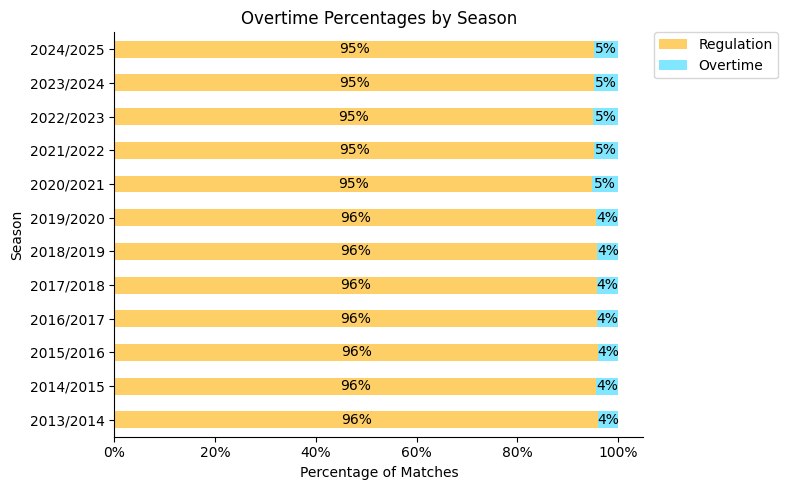

In [70]:
# Plotting match counts by season and using color to differentiate overtime or not
plot_data = recategorized.replace({True : 'Overtime',
                                   False : 'Regulation'}).groupby('season')['is_overtime'].value_counts(normalize=True).unstack()
plot_data = plot_data[['Regulation', 'Overtime']]
g = plot_data.plot(kind='barh', stacked=True, figsize=(8,5), cmap='managua')

g.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Annotating with percentages
for i, (index, row) in enumerate(plot_data.iterrows()):
    cumulative = 0
    for result in plot_data.columns:
        value = row[result]
        if pd.notna(value) and value > 0:  # only annotate if >5%
            g.text(cumulative + value / 2, i, f'{value:.0%}', va='center', ha='center', fontsize=10)
            cumulative += value

label_and_despine('Overtime Percentages by Season', 'Percentage of Matches', 'Season')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../output/figures/overtime_percentage_by_season.png')

Continuing the trend of result types, the percentage of matches that go to overtime has also stayed incredibly consistent throughout the years.

# Team-Level Analysis

Now I want to take a closer look at the individual teams, specifically the better teams, and see if there is anything that stands out about their performance in relation to each other

To look at team specific performance I'm going to need every match portrayed from both team's point of view, so I need to effectively duplicate each match and swap the primary and opponent wrestler

In [71]:
# Helper function to duplicate matches
def double_matches(df):
    df_b = df.copy()
    df_b['wrestler_id'] = df['opponent_id']
    df_b['opponent_id'] = df['wrestler_id']
    df_b['wrestler'] = df['opponent']
    df_b['opponent'] = df['wrestler']
    df_b['wrestler_school'] = df['opponent_school']
    df_b['opponent_school'] = df['wrestler_school']
    df_b['result'] = np.where(df['result'] == 'W', 'L', 'W')

    result = pd.concat([df, df_b])
    return result.sort_values(['date', 'wrestler_id']).reset_index()

df = double_matches(recategorized)

In [72]:
# Creating better binary columns for win and bonus
df.loc[:, 'is_win'] = df['result'] == 'W'
df.loc[:, 'is_bonus_win'] = (df['result_type'].isin(['MD', 'TF', 'FALL'])) & (df['result'] == 'W')

In [73]:
# Standardizing naming to ensure capitalization doesn't separate a team's matches
df['wrestler_school'] = df['wrestler_school'].str.upper()

In [74]:
# Aggregating stats by team
team_stats = (
    df.groupby('wrestler_school')
        .agg(
            total_matches=('wrestler_school', 'count'),
            win_rate=('is_win', 'mean'),
            bonus_rate=('is_bonus_win', 'mean')
        )
        .sort_values('win_rate', ascending=False)
)

In [75]:
# Aggregating yearly stats by team
team_season_stats = (
    df.groupby(['season', 'wrestler_school'])
        .agg(
            matches=('wrestler_school', 'count'),
            win_rate=('is_win', 'mean'),
            bonus_rate=('is_bonus_win', 'mean')
        )
        .reset_index()
)

In [76]:
# Ensuring only D1 teams are listed
teams = []
for team in os.listdir('../data/raw/team_results'):
    team = team.replace('_', ' ').upper()
    teams.append(team)
team_stats = team_stats[team_stats.index.isin(teams)]

In [77]:
team_stats.head(10)

,total_matches,win_rate,bonus_rate
wrestler_school,,,
IOWA,6286,0.713013,0.369392
OKLAHOMA STATE,6801,0.711807,0.369799
PENN STATE,5798,0.708693,0.397723
NC STATE,6791,0.666176,0.337358
NEBRASKA,6742,0.665085,0.323346
MISSOURI,7856,0.664842,0.318992
OHIO STATE,6470,0.657496,0.321329
CORNELL,5689,0.651608,0.307260
VIRGINIA TECH,6115,0.632379,0.279967


Unsurprisingly, the three main powerhouses of college wrestling (Iowa, Oklahoma State, and Penn State) have the highest win rates during the observed period.

The rest of the list is also mostly expected, containing more well renowned programs from the Big 10, ACC, Big 12, and the lone Ivy League champions Cornell.

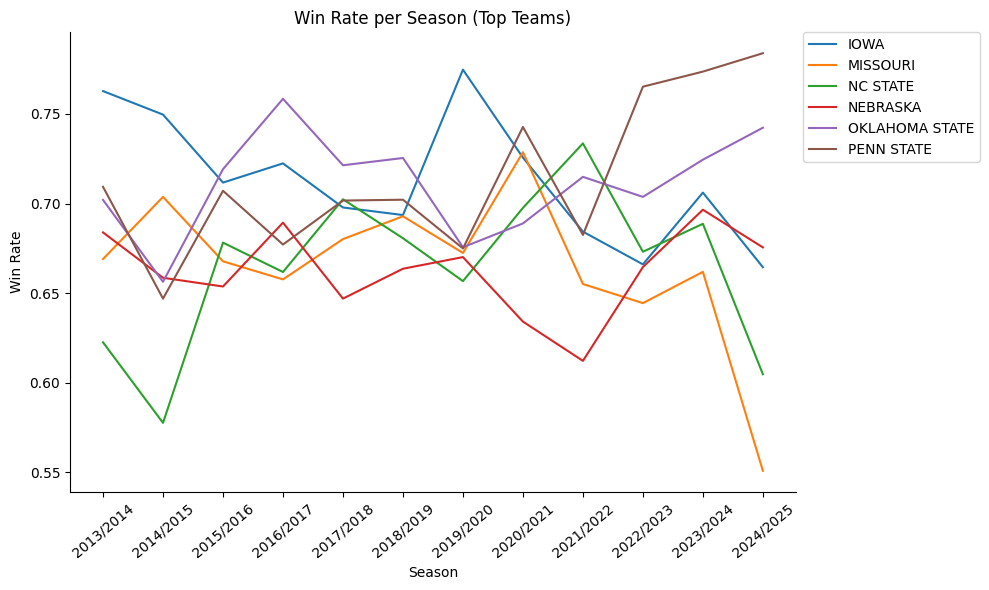

In [78]:
# Selecting top 6 teams by win percentage
top_teams = team_stats.head(6).index.tolist()

# Line chart of yearly win percentage for top teams
plt.figure(figsize=(10,6))
sns.lineplot(
    data=team_season_stats[team_season_stats['wrestler_school'].isin(top_teams)],
    x='season', y='win_rate', hue='wrestler_school'
)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
label_and_despine('Win Rate per Season (Top Teams)', 'Season', 'Win Rate')
plt.xticks(rotation=40)
plt.tight_layout()
plt.savefig('../output/figures/win_rate_by_season_top_teams.png')

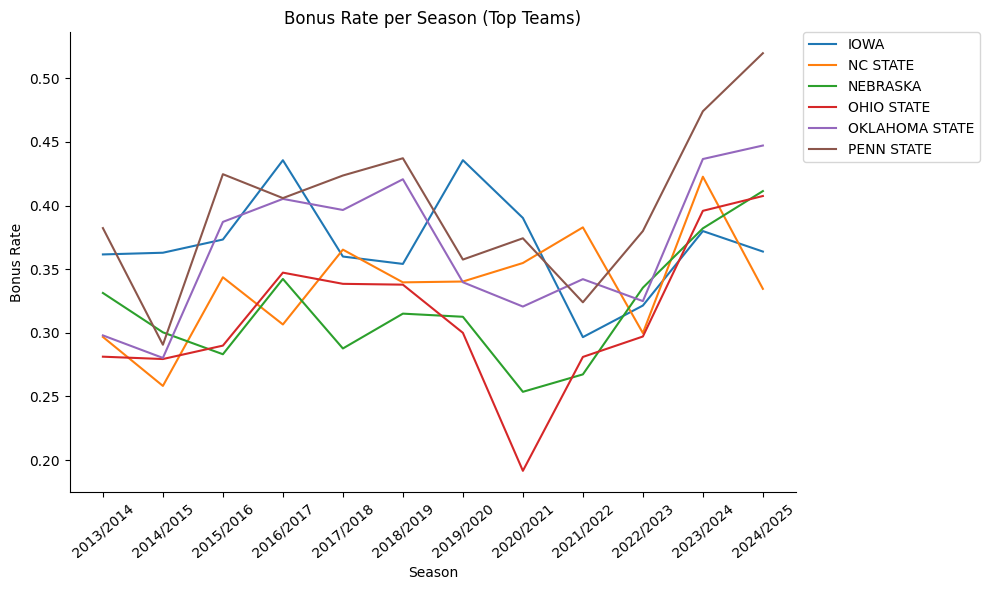

In [79]:
# Selecting top 6 teams by bonus percentage
top_teams_bonus = team_stats.sort_values('bonus_rate', ascending=False).head(6).index.tolist()

# Line chart of yearly bonus win percentage for top teams
plt.figure(figsize=(10,6))
sns.lineplot(
    data=team_season_stats[team_season_stats['wrestler_school'].isin(top_teams_bonus)],
    x='season', y='bonus_rate', hue='wrestler_school'
)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
label_and_despine('Bonus Rate per Season (Top Teams)', 'Season', 'Bonus Rate')
plt.xticks(rotation=40)
plt.tight_layout()
plt.savefig('../output/figures/bonus_win_rate_by_season_top_teams.png')

For fans of college wrestling, the two graphs above are not very surprising either. 

Penn State has had a chokehold on Division 1 wrestling since the addition of head coach Cael Sanderson, dominating not only in the win column, but also by bonus points. Other successes include Oklahoma State with their recent addition of head coach David Taylor, Nebraska with their collection of up-and-coming talent, and the Brands brothers over in Wrestletown with the Iowa program.

# Wrestler-Specific Analysis

A pretty clear list of names comes to mind whenever I think about great college wrestlers from the past decade, but I'd like to get some clear visualizations about the dominance that some wrestlers were able to acheive.

In [80]:
# Aggregating stats by wrestler
wrestler_stats = (
    df.groupby(['wrestler_id', 'wrestler'])
        .agg(
            total_matches=('wrestler_id', 'count'),
            win_rate=('is_win', 'mean'),
            bonus_rate=('is_bonus_win', 'mean'),
            matches_won=('is_win', 'sum')
        )
        .sort_values('win_rate', ascending=False)
        .reset_index()
)

In [81]:
# Aggregating yearly stats by wrestler
wrestler_season_stats = (
    df.groupby(['season', 'wrestler_id'])
        .agg(
            matches=('wrestler_id', 'count'),
            win_rate=('is_win', 'mean'),
            bonus_rate=('is_bonus_win', 'mean')
        )
        .reset_index()
)

In [82]:
# Recording how many seasons each wrestler has participated in
seasons_per_wrestler = (
    wrestler_season_stats.groupby('wrestler_id')['season']
    .nunique()
    .reset_index(name='num_seasons')
)
full_career_ids = seasons_per_wrestler[seasons_per_wrestler['num_seasons'] >= 4]['wrestler_id']

# Removing wrestlers in dataframe who appear in less than 4 years (data doesn't cover full career)
wrestler_stats = wrestler_stats[wrestler_stats['wrestler_id'].isin(full_career_ids)]
wrestler_season_stats = wrestler_season_stats[wrestler_season_stats['wrestler_id'].isin(full_career_ids)]

In [83]:
# Adding some supplementary statistics to help with visualization
wrestler_stats['matches_lost'] = wrestler_stats['total_matches'] - wrestler_stats['matches_won']

# Creating Bayesian adjusted win and bonus rates to penalize low match counts
wrestler_stats['adjusted_win_rate'] = (
    (20 + wrestler_stats['win_rate'] * wrestler_stats['total_matches']) /
    (20 + 10 + wrestler_stats['total_matches'])
)
wrestler_stats['adjusted_bonus_rate'] = (
    (10 + wrestler_stats['bonus_rate'] * wrestler_stats['total_matches']) /
    (10 + 20 + wrestler_stats['total_matches'])
)

In [84]:
# Selecting top 20 wrestlers by adjusted win percentage
top_wrestlers = (
    wrestler_stats.sort_values('adjusted_win_rate', ascending=False)
    .head(20)
)

# Removing Levi since he competed unofficially for Penn State as a senior in high school, 2025/2026 will be his fourth official year
top_wrestlers = top_wrestlers[top_wrestlers['wrestler'] != 'Levi Haines']

In [85]:
top_wrestlers

,wrestler_id,wrestler,total_matches,win_rate,bonus_rate,matches_won,matches_lost,adjusted_win_rate,adjusted_bonus_rate
1434,49110,Yianni Diakomihalis,116,0.982759,0.620690,114,2,0.917808,0.561644
1437,11781,Zain Retherford,128,0.976562,0.750000,125,3,0.917722,0.670886
1441,58819,Carter Starocci,127,0.968504,0.598425,123,4,0.910828,0.547771
1444,13114,J'den Cox,136,0.963235,0.551471,131,5,0.909639,0.512048
1455,56724,Parker Keckeisen,156,0.955128,0.673077,149,7,0.908602,0.618280
1445,39501,Zahid Valencia,132,0.962121,0.765152,127,5,0.907407,0.685185
1439,50624,Gable Steveson,109,0.972477,0.724771,106,3,0.906475,0.640288
1451,20302,Bo Nickal,141,0.957447,0.716312,135,6,0.906433,0.649123
1446,13466,Isaiah Martinez,127,0.960630,0.645669,122,5,0.904459,0.585987
1453,20303,Jason Nolf,137,0.956204,0.810219,131,6,0.904192,0.724551


In [86]:
top_wrestlers.sort_values('adjusted_bonus_rate', ascending=False)

,wrestler_id,wrestler,total_matches,win_rate,bonus_rate,matches_won,matches_lost,adjusted_win_rate,adjusted_bonus_rate
1453,20303,Jason Nolf,137,0.956204,0.810219,131,6,0.904192,0.724551
1445,39501,Zahid Valencia,132,0.962121,0.765152,127,5,0.907407,0.685185
1437,11781,Zain Retherford,128,0.976562,0.750000,125,3,0.917722,0.670886
1451,20302,Bo Nickal,141,0.957447,0.716312,135,6,0.906433,0.649123
1439,50624,Gable Steveson,109,0.972477,0.724771,106,3,0.906475,0.640288
1455,56724,Parker Keckeisen,156,0.955128,0.673077,149,7,0.908602,0.618280
1464,12580,Gabe Dean,131,0.946565,0.671756,124,7,0.894410,0.608696
1454,61119,Keegan O'Toole,113,0.955752,0.672566,108,5,0.895105,0.601399
1446,13466,Isaiah Martinez,127,0.960630,0.645669,122,5,0.904459,0.585987
1448,54280,Aaron Brooks,100,0.960000,0.640000,96,4,0.892308,0.569231


In [87]:
top_wrestlers.sort_values('total_matches', ascending=False)

,wrestler_id,wrestler,total_matches,win_rate,bonus_rate,matches_won,matches_lost,adjusted_win_rate,adjusted_bonus_rate
1455,56724,Parker Keckeisen,156,0.955128,0.673077,149,7,0.908602,0.618280
1463,51126,David Carr,150,0.946667,0.566667,142,8,0.900000,0.527778
1495,44595,Hayden Hidlay,146,0.904110,0.609589,132,14,0.863636,0.562500
1451,20302,Bo Nickal,141,0.957447,0.716312,135,6,0.906433,0.649123
1472,49263,Daton Fix,138,0.934783,0.565217,129,9,0.886905,0.523810
1453,20303,Jason Nolf,137,0.956204,0.810219,131,6,0.904192,0.724551
1444,13114,J'den Cox,136,0.963235,0.551471,131,5,0.909639,0.512048
1445,39501,Zahid Valencia,132,0.962121,0.765152,127,5,0.907407,0.685185
1464,12580,Gabe Dean,131,0.946565,0.671756,124,7,0.894410,0.608696
1437,11781,Zain Retherford,128,0.976562,0.750000,125,3,0.917722,0.670886


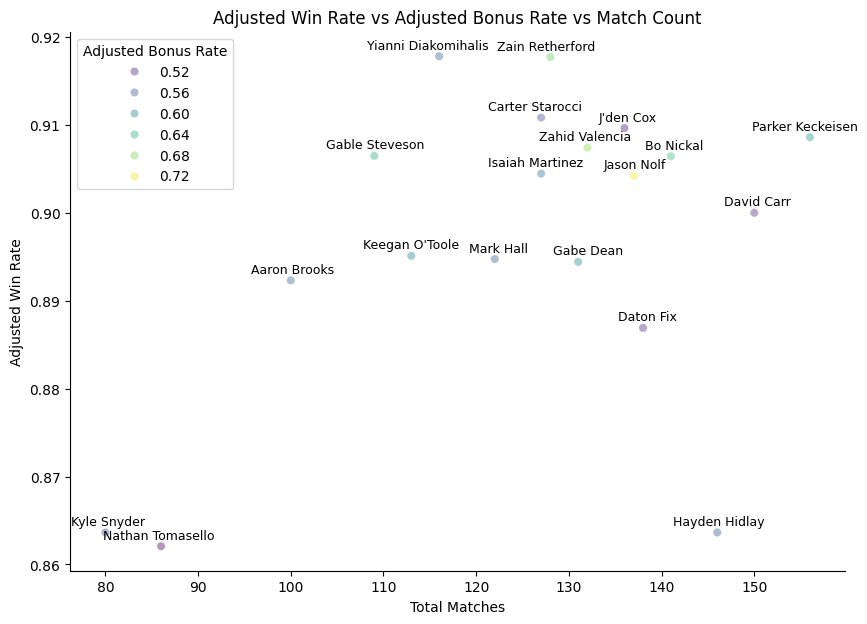

In [88]:
# Plotting adjusted win rate versus match count with adjusted bonus rate as color
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=top_wrestlers,
    x='total_matches',
    y='adjusted_win_rate',
    hue='adjusted_bonus_rate',
    alpha=0.4,
    palette='viridis'
).legend(title='Adjusted Bonus Rate')

for _, row in top_wrestlers.iterrows():
    plt.text(
        row['total_matches'] - (len(row['wrestler']) / 2) + 1.75,
        row['adjusted_win_rate'] + 0.0012,
        row['wrestler'],
        fontsize=9,
        color='black',
        ha='left',
        va='center'
    )

label_and_despine("Adjusted Win Rate vs Adjusted Bonus Rate vs Match Count", "Total Matches", "Adjusted Win Rate")
plt.savefig('../output/figures/adjusted_win_rate_vs_adjusted_bonus_rate_vs_match_count.png')

This graphic contains tons of information, and while the Bayesian adjusted rates are rather arbitrary, the scatterplot displays a clear image of which wrestlers have dominated over the collected time period. A significant majority of the wrestlers listed have won multiple NCAA championships, including Carter Starocci, the first every five-time NCAA wrestling champion. 

Other notable wrestlers include four-time NCAA champions Yianni Diakomihalis and Aaron Brooks, bonus point machine and three-time NCAA champion Jason Nolf **(who scores the highest adjusted bonus rate of over 70%!)**, and two-time NCAA champion and ASU standout Zahid Valencia.

# Conclusion

As with all data, there are thousands of graphs and charts that could be made and analyzed, and as both a wrestling fan and data enthusiast, I would love to dive deeper and truly explore the data I've collected, but for the scope of this project I'm satisfied with the figures I've created so far.

Being an avid college wrestling fan, most of the results I generated were relatively unsurprising, but being able to match numbers to the trends I've seen on TV was really interesting, and helped me see the bigger picture of college wrestling history from 2013 to the present.